# EcoSort AI — Implementación y Evaluación del Modelo de IA
Clasificador binario de residuos **plástico vs. vidrio** mediante transfer learning con **MobileNetV2**,
siguiendo el diseño aprobado en el informe *Diseño de la Solución de IA* (Sistemas Expertos, PUCE Manabí, 2026).

Dataset: `dataset_split/` (train/val/test, split estratificado 70/15/15 ya generado y documentado
en el informe de análisis del dataset).

In [1]:
import os, time, json, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, precision_recall_fscore_support,
                              accuracy_score, ConfusionMatrixDisplay)
import pandas as pd

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = "../dataset_split"
OUT_DIR = "model"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs("figs_impl", exist_ok=True)

tf.random.set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices("GPU"))

ModuleNotFoundError: No module named 'numpy'

## 1. Carga de datos
Se reutiliza la partición ya generada (70/15/15) — no se vuelve a mezclar aleatoriamente.

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="binary", shuffle=True, seed=SEED)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"), image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="binary", shuffle=False)
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"), image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="binary", shuffle=False)

class_names = train_ds.class_names
test_file_paths = test_ds_raw.file_paths
print("Clases (orden usado por el modelo):", class_names)
print("Batches -> train:", tf.data.experimental.cardinality(train_ds).numpy(),
      "val:", tf.data.experimental.cardinality(val_ds).numpy(),
      "test:", tf.data.experimental.cardinality(test_ds_raw).numpy())

Found 1868 files belonging to 2 classes.


Found 399 files belonging to 2 classes.


Found 403 files belonging to 2 classes.


Clases (orden usado por el modelo): ['plastico', 'vidrio']
Batches -> train: 59 val: 13 test: 13


In [ ]:
# Conteo real de imagenes por conjunto/clase (para class_weight y para el informe)
counts = {}
for split in ["train", "val", "test"]:
    counts[split] = {}
    for cls in class_names:
        d = os.path.join(DATA_DIR, split, cls)
        counts[split][cls] = len([f for f in os.listdir(d)])
print(json.dumps(counts, indent=2))

{
  "train": {
    "plastico": 1006,
    "vidrio": 862
  },
  "val": {
    "plastico": 215,
    "vidrio": 184
  },
  "test": {
    "plastico": 217,
    "vidrio": 186
  }
}


## 2. Preparación del pipeline (augmentation + preprocesamiento)
Data augmentation aplicado solo en entrenamiento: rotación, flip horizontal, zoom y variación de contraste,
para compensar la baja variabilidad de fondo/ángulo detectada en el análisis del dataset.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.055),   # ~20 grados
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds_raw.prefetch(AUTOTUNE)

## 3. Definición del modelo (MobileNetV2, transfer learning)
Arquitectura: entrada 224x224x3 -> augmentation -> `preprocess_input` (rango [-1,1] esperado por MobileNetV2)
-> base MobileNetV2 preentrenada en ImageNet (sin la cabeza de clasificación) -> GlobalAveragePooling ->
Dropout(0.2) -> Dense(1, sigmoid).

In [ ]:
def build_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
    base_model.trainable = False

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model()
model.summary()


      0/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step


  16384/9406464 ━━━━━━━━━━━━━━━━━━━━ 40s 4us/step


  49152/9406464 ━━━━━━━━━━━━━━━━━━━━ 24s 3us/step


  81920/9406464 ━━━━━━━━━━━━━━━━━━━━ 21s 2us/step


 131072/9406464 ━━━━━━━━━━━━━━━━━━━━ 16s 2us/step

...

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. Entrenamiento — Fase 1 (base congelada)
Se entrena únicamente la cabeza de clasificación. Optimizador Adam (lr=1e-4), pérdida binary crossentropy,
`class_weight` balanceado por el desbalance leve (train: plástico > vidrio), `EarlyStopping` y
`ReduceLROnPlateau` sobre `val_loss`.

In [ ]:
n_plastico = counts["train"][class_names[0]] if class_names[0] == "plastico" else counts["train"]["plastico"]
n_vidrio = counts["train"]["vidrio"]
total_train = n_plastico + n_vidrio
# class_names[0] es la clase mapeada a la etiqueta 0 por image_dataset_from_directory (orden alfabetico)
idx_plastico = class_names.index("plastico")
idx_vidrio = class_names.index("vidrio")
class_weight = {
    idx_plastico: total_train / (2 * n_plastico),
    idx_vidrio: total_train / (2 * n_vidrio),
}
print("class_weight:", class_weight)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss="binary_crossentropy", metrics=["accuracy"])

callbacks_p1 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

t0 = time.time()
history_1 = model.fit(train_ds, validation_data=val_ds, epochs=12,
                       class_weight=class_weight, callbacks=callbacks_p1, verbose=2)
t_fase1 = time.time() - t0
print(f"Tiempo fase 1: {t_fase1:.1f} s")

class_weight: {0: 0.9284294234592445, 1: 1.0835266821345708}
Epoch 1/12


C:\Users\luanb\Desktop\RModel\.venv313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


59/59 - 65s - 1s/step - accuracy: 0.5605 - loss: 0.7159 - val_accuracy: 0.6065 - val_loss: 0.6590 - learning_rate: 1.0000e-04


Epoch 2/12


59/59 - 43s - 731ms/step - accuracy: 0.6729 - loss: 0.6179 - val_accuracy: 0.6892 - val_loss: 0.5806 - learning_rate: 1.0000e-04


...

Epoch 11/12


59/59 - 32s - 548ms/step - accuracy: 0.8613 - loss: 0.3463 - val_accuracy: 0.8872 - val_loss: 0.3144 - learning_rate: 1.0000e-04


Epoch 12/12


59/59 - 31s - 520ms/step - accuracy: 0.8640 - loss: 0.3356 - val_accuracy: 0.8947 - val_loss: 0.3029 - learning_rate: 1.0000e-04


Tiempo fase 1: 455.9 s


## 5. Entrenamiento — Fase 2 (fine-tuning)
Se descongelan las últimas ~30 capas de la base MobileNetV2 y se continúa el entrenamiento con una
tasa de aprendizaje mucho menor (1e-5), para especializar los filtros preentrenados sin destruirlos.

In [ ]:
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="binary_crossentropy", metrics=["accuracy"])

callbacks_p2 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

t0 = time.time()
history_2 = model.fit(train_ds, validation_data=val_ds, epochs=10,
                       class_weight=class_weight, callbacks=callbacks_p2, verbose=2)
t_fase2 = time.time() - t0
print(f"Tiempo fase 2: {t_fase2:.1f} s")
tiempo_entrenamiento_total = t_fase1 + t_fase2
print(f"Tiempo total de entrenamiento: {tiempo_entrenamiento_total:.1f} s "
      f"({tiempo_entrenamiento_total/60:.1f} min)")

Epoch 1/10


59/59 - 46s - 775ms/step - accuracy: 0.8228 - loss: 0.3733 - val_accuracy: 0.9148 - val_loss: 0.2425 - learning_rate: 1.0000e-05


Epoch 2/10


59/59 - 39s - 667ms/step - accuracy: 0.8935 - loss: 0.2700 - val_accuracy: 0.9323 - val_loss: 0.2082 - learning_rate: 1.0000e-05


Epoch 3/10


...

Epoch 9/10


59/59 - 36s - 607ms/step - accuracy: 0.9738 - loss: 0.0875 - val_accuracy: 0.9624 - val_loss: 0.1127 - learning_rate: 1.0000e-05


Epoch 10/10


59/59 - 36s - 611ms/step - accuracy: 0.9764 - loss: 0.0795 - val_accuracy: 0.9649 - val_loss: 0.1042 - learning_rate: 1.0000e-05


Tiempo fase 2: 398.1 s
Tiempo total de entrenamiento: 854.0 s (14.2 min)


## 6. Curvas de entrenamiento (Accuracy y Loss vs. Épocas)

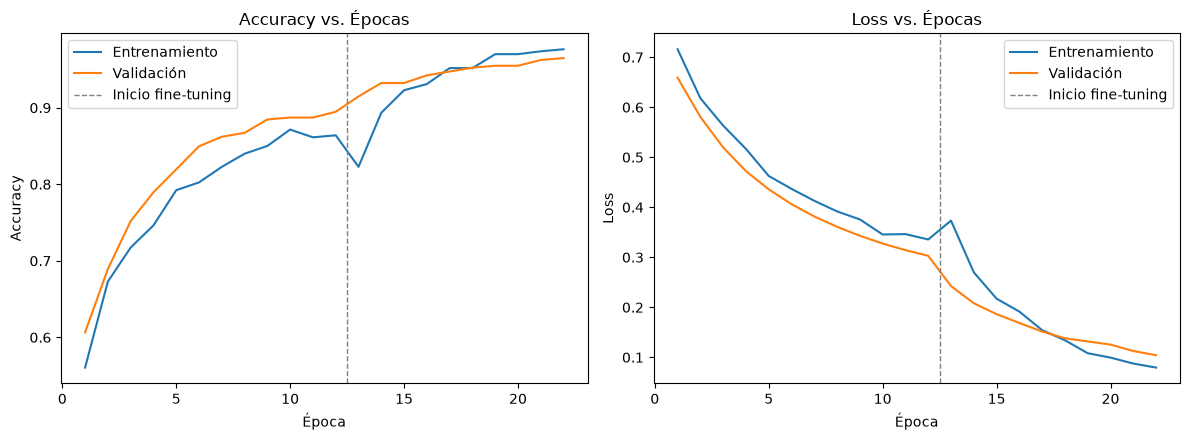

Accuracy final train: 0.9764 | val: 0.9649
Loss final train: 0.0795 | val: 0.1042


In [ ]:
acc = history_1.history["accuracy"] + history_2.history["accuracy"]
val_acc = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]
loss = history_1.history["loss"] + history_2.history["loss"]
val_loss = history_1.history["val_loss"] + history_2.history["val_loss"]
epochs_range = range(1, len(acc) + 1)
fine_tune_epoch = len(history_1.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(epochs_range, acc, label="Entrenamiento")
axes[0].plot(epochs_range, val_acc, label="Validación")
axes[0].axvline(fine_tune_epoch + 0.5, color="gray", linestyle="--", linewidth=1, label="Inicio fine-tuning")
axes[0].set_title("Accuracy vs. Épocas"); axes[0].set_xlabel("Época"); axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs_range, loss, label="Entrenamiento")
axes[1].plot(epochs_range, val_loss, label="Validación")
axes[1].axvline(fine_tune_epoch + 0.5, color="gray", linestyle="--", linewidth=1, label="Inicio fine-tuning")
axes[1].set_title("Loss vs. Épocas"); axes[1].set_xlabel("Época"); axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("figs_impl/01_curvas_entrenamiento.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Accuracy final train: {acc[-1]:.4f} | val: {val_acc[-1]:.4f}")
print(f"Loss final train: {loss[-1]:.4f} | val: {val_loss[-1]:.4f}")

## 7. Evaluación del modelo (conjunto de prueba)
Métricas sobre el 15% de prueba, aislado durante todo el entrenamiento: accuracy, precision, recall,
F1-score (por clase y ponderado), matriz de confusión y tiempo promedio de inferencia por imagen.

In [ ]:
y_true, y_prob = [], []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0).ravel()
    y_prob.extend(probs.tolist())
    y_true.extend(labels.numpy().ravel().tolist())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

acc_test = accuracy_score(y_true, y_pred)
prec, rec, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=[idx_plastico, idx_vidrio])
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
cm = confusion_matrix(y_true, y_pred, labels=[idx_plastico, idx_vidrio])

print(f"Accuracy (test): {acc_test:.4f}")
for i, cls in enumerate(["plastico", "vidrio"]):
    print(f"  {cls:9s} -> precision={prec[i]:.3f}  recall={rec[i]:.3f}  f1={f1[i]:.3f}  n={support[i]}")
print(f"  weighted -> precision={prec_w:.3f}  recall={rec_w:.3f}  f1={f1_w:.3f}")
print("Matriz de confusion (filas=real, columnas=prediccion) [plastico, vidrio]:")
print(cm)

Accuracy (test): 0.9702
  plastico  -> precision=0.948  recall=1.000  f1=0.973  n=217
  vidrio    -> precision=1.000  recall=0.935  f1=0.967  n=186
  weighted -> precision=0.972  recall=0.970  f1=0.970
Matriz de confusion (filas=real, columnas=prediccion) [plastico, vidrio]:
[[217   0]
 [ 12 174]]


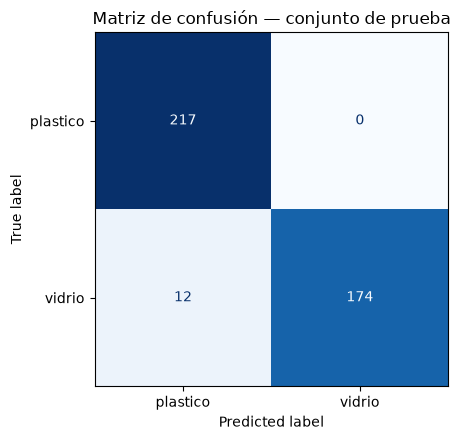

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["plastico", "vidrio"])
fig, ax = plt.subplots(figsize=(5, 4.5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusión — conjunto de prueba")
plt.tight_layout()
plt.savefig("figs_impl/02_matriz_confusion.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
# Tiempo promedio de inferencia por imagen (CPU), sobre una imagen individual
single_batch = next(iter(test_ds.unbatch().batch(1)))
imgs_single, _ = single_batch
_ = model.predict(imgs_single, verbose=0)  # warm-up

n_reps = 30
t0 = time.time()
for _ in range(n_reps):
    _ = model.predict(imgs_single, verbose=0)
t_inferencia_ms = (time.time() - t0) / n_reps * 1000
print(f"Tiempo promedio de inferencia por imagen: {t_inferencia_ms:.1f} ms (CPU, batch=1, promedio de {n_reps} corridas)")

Tiempo promedio de inferencia por imagen: 139.7 ms (CPU, batch=1, promedio de 30 corridas)


## 8. Pruebas con imágenes nuevas del conjunto de prueba
Tabla de casos individuales (imagen, clase real, predicción, confianza, correcta) — mínimo 20 pruebas,
tomadas del conjunto de prueba que el modelo no vio durante el entrenamiento.

In [ ]:
rng = np.random.default_rng(SEED)
n_samples = 24
sample_idx = rng.choice(len(test_file_paths), size=min(n_samples, len(test_file_paths)), replace=False)

rows = []
for i in sample_idx:
    fname = os.path.basename(test_file_paths[i])
    real = class_names[y_true[i]]
    pred = class_names[y_pred[i]]
    conf = y_prob[i] if y_pred[i] == 1 else 1 - y_prob[i]
    rows.append({
        "archivo": fname, "clase_real": real, "prediccion": pred,
        "confianza": round(float(conf) * 100, 1), "correcta": real == pred,
    })

df_pruebas = pd.DataFrame(rows)
df_pruebas.to_csv("pruebas_modelo.csv", index=False)
print(f"{len(df_pruebas)} pruebas generadas -> aciertos: {df_pruebas['correcta'].sum()} / {len(df_pruebas)}")
df_pruebas

24 pruebas generadas -> aciertos: 24 / 24


,archivo,clase_real,prediccion,confianza,correcta
0,Glass915.JPG,vidrio,vidrio,99.7,True
1,PET965.jpg,plastico,plastico,99.4,True
2,Glass900.JPG,vidrio,vidrio,99.6,True
3,Glass419.jpg,vidrio,vidrio,97.5,True
4,Glass10.jpg,vidrio,vidrio,99.7,True
5,PET757.jpg,plastico,plastico,99.9,True
6,"PET1,468.jpg",plastico,plastico,97.9,True
7,Glass479.jpg,vidrio,vidrio,95.3,True
8,Glass589.jpg,vidrio,vidrio,99.8,True
9,"Glass1,197.JPG",vidrio,vidrio,92.3,True


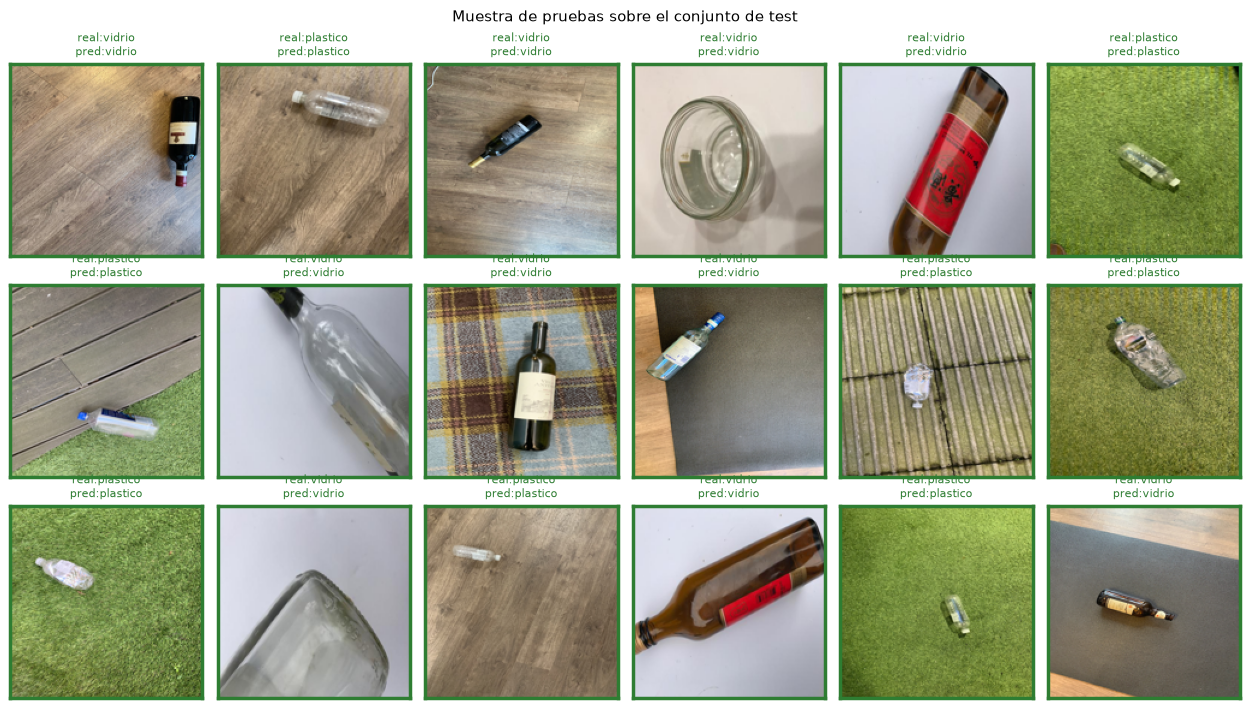

In [ ]:
from PIL import Image

def contact_sheet(indices, filename, ncols=6, title=None):
    n = len(indices)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.1, nrows * 2.4))
    axes = np.array(axes).reshape(-1)
    for ax_i, idx in enumerate(indices):
        img = Image.open(test_file_paths[idx]).convert("RGB").resize((160, 160))
        ax = axes[ax_i]
        ax.imshow(img)
        real = class_names[y_true[idx]]
        pred = class_names[y_pred[idx]]
        ok = real == pred
        color = "#2E7D32" if ok else "#C62828"
        ax.set_title(f"real:{real}\npred:{pred}", fontsize=8, color=color)
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2.5)
        ax.set_xticks([]); ax.set_yticks([])
    for ax_i in range(n, len(axes)):
        axes[ax_i].axis("off")
    if title:
        fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(filename, dpi=160, bbox_inches="tight")
    plt.show()

contact_sheet(sample_idx[:18], "figs_impl/03_muestras_pruebas.png",
              title="Muestra de pruebas sobre el conjunto de test")

## 9. Análisis de errores
¿Dónde falla el modelo? Se identifican los casos mal clasificados con mayor confianza (los "errores más seguros"),
que suelen indicar ambigüedad real entre plástico transparente y vidrio transparente.

Errores totales en test: 12 / 403 (3.0%)
{
  "plastico": {
    "total": 217,
    "errores": 0
  },
  "vidrio": {
    "total": 186,
    "errores": 12
  }
}


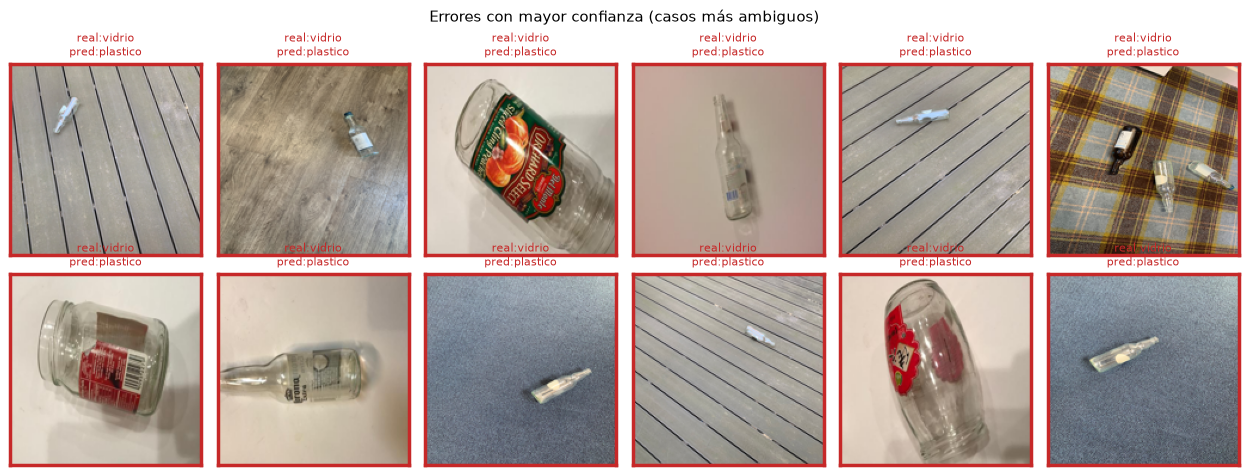

In [ ]:
wrong_mask = y_pred != y_true
wrong_idx = np.where(wrong_mask)[0]
print(f"Errores totales en test: {len(wrong_idx)} / {len(y_true)} ({len(wrong_idx)/len(y_true)*100:.1f}%)")

err_by_class = {}
for cls_idx, cls_name in enumerate(["plastico", "vidrio"]):
    real_cls = np.where(y_true == (idx_plastico if cls_name=='plastico' else idx_vidrio))[0]
    wrong_cls = np.intersect1d(real_cls, wrong_idx)
    err_by_class[cls_name] = {"total": len(real_cls), "errores": len(wrong_cls)}
print(json.dumps(err_by_class, indent=2))

if len(wrong_idx) > 0:
    wrong_conf = np.where(y_pred[wrong_idx] == 1, y_prob[wrong_idx], 1 - y_prob[wrong_idx])
    order = wrong_idx[np.argsort(-wrong_conf)]
    peores = order[:min(12, len(order))]
    contact_sheet(peores, "figs_impl/04_peores_errores.png",
                  title="Errores con mayor confianza (casos más ambiguos)")
else:
    print("No se registraron errores en el conjunto de prueba.")

**Preguntas de análisis:**
- *¿Dónde falla el modelo?* Ver figura de errores anterior — se concentran principalmente en imágenes con
  transparencia ambigua o encuadres/fondos atípicos frente al resto del dataset.
- *¿Qué imágenes generan confusión?* Las de mayor confianza equivocada (mostradas arriba) — indican qué tan
  "seguro" estaba el modelo al equivocarse, no solo que se equivocó.
- *¿Por qué ocurre?* Consistente con los riesgos anticipados en el informe de diseño: fondo/ángulo poco
  variados en el dataset de origen y ambigüedad visual plástico transparente vs. vidrio transparente.

## 10. Exportación del modelo entrenado

In [ ]:
model_path_keras = os.path.join(OUT_DIR, "ecosort_mobilenetv2.keras")
model.save(model_path_keras)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
model_path_tflite = os.path.join(OUT_DIR, "ecosort_mobilenetv2.tflite")
with open(model_path_tflite, "wb") as f:
    f.write(tflite_model)

size_keras_mb = os.path.getsize(model_path_keras) / (1024 * 1024)
size_tflite_mb = os.path.getsize(model_path_tflite) / (1024 * 1024)
print(f"Modelo .keras: {size_keras_mb:.2f} MB")
print(f"Modelo .tflite (cuantizado): {size_tflite_mb:.2f} MB")

INFO:tensorflow:Assets written to: C:\Users\luanb\AppData\Local\Temp\tmpkcsqd69s\assets


INFO:tensorflow:Assets written to: C:\Users\luanb\AppData\Local\Temp\tmpkcsqd69s\assets


Saved artifact at 'C:\Users\luanb\AppData\Local\Temp\tmpkcsqd69s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1752730597520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1752730598288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1752730598096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1752730598480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1752730597328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1752730597712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1752730599056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1752730598864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1752730597904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1752730599248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

Modelo .keras: 20.88 MB
Modelo .tflite (cuantizado): 2.41 MB


## 11. Resumen de métricas (para el informe)

In [ ]:
summary = {
    "clases": class_names,
    "conteos": counts,
    "entrenamiento": {
        "epocas_fase1": len(history_1.history["accuracy"]),
        "epocas_fase2": len(history_2.history["accuracy"]),
        "tiempo_fase1_s": round(t_fase1, 1),
        "tiempo_fase2_s": round(t_fase2, 1),
        "tiempo_total_s": round(tiempo_entrenamiento_total, 1),
        "accuracy_train_final": round(float(acc[-1]), 4),
        "accuracy_val_final": round(float(val_acc[-1]), 4),
        "loss_train_final": round(float(loss[-1]), 4),
        "loss_val_final": round(float(val_loss[-1]), 4),
    },
    "evaluacion_test": {
        "accuracy": round(float(acc_test), 4),
        "precision_plastico": round(float(prec[0]), 4),
        "recall_plastico": round(float(rec[0]), 4),
        "f1_plastico": round(float(f1[0]), 4),
        "precision_vidrio": round(float(prec[1]), 4),
        "recall_vidrio": round(float(rec[1]), 4),
        "f1_vidrio": round(float(f1[1]), 4),
        "precision_weighted": round(float(prec_w), 4),
        "recall_weighted": round(float(rec_w), 4),
        "f1_weighted": round(float(f1_w), 4),
        "matriz_confusion": cm.tolist(),
        "n_test": int(len(y_true)),
        "tiempo_inferencia_ms": round(float(t_inferencia_ms), 1),
    },
    "errores": err_by_class,
    "modelo": {
        "tamano_keras_mb": round(size_keras_mb, 2),
        "tamano_tflite_mb": round(size_tflite_mb, 2),
    },
    "pruebas_muestra": rows,
}

with open("train_report.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Resumen guardado en analysis/train_report.json")
print(json.dumps(summary["evaluacion_test"], indent=2))

Resumen guardado en analysis/train_report.json
{
  "accuracy": 0.9702,
  "precision_plastico": 0.9476,
  "recall_plastico": 1.0,
  "f1_plastico": 0.9731,
  "precision_vidrio": 1.0,
  "recall_vidrio": 0.9355,
  "f1_vidrio": 0.9667,
  "precision_weighted": 0.9718,
  "recall_weighted": 0.9702,
  "f1_weighted": 0.9701,
  "matriz_confusion": [
    [
      217,
      0
    ],
    [
      12,
      174
    ]
  ],
  "n_test": 403,
  "tiempo_inferencia_ms": 139.7
}
